In [38]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5070


In [39]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import glob
import random
import yaml

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# import IPython.display as display
from PIL import Image
import cv2

from ultralytics import YOLO


In [40]:
def read_yaml_file(file_path):
    with open(file_path, 'r') as file:
        try:
            data = yaml.safe_load(file)
            return data
        except yaml.YAMLError as e:
            print("Error reading YAML:", e)
            return None

# print it with newlines
def print_yaml_data(data):
    formatted_yaml = yaml.dump(data, default_style=False)
    print(formatted_yaml)

file_path = os.path.join('data.yaml')
yaml_data = read_yaml_file(file_path)

if yaml_data:
    print_yaml_data(r"C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\data.yaml")


C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\data.yaml
...



Type:  <class 'PIL.PngImagePlugin.PngImageFile'> \n
Shape:  (460, 620, 3) \n


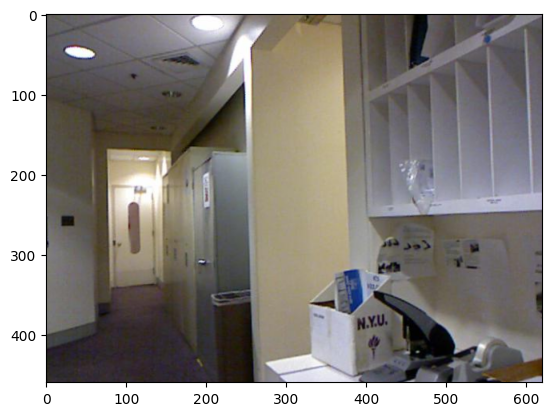

In [41]:
def display_image(image, print_info = True, hide_axis = False):
    if isinstance(image, str):  # Check if it's a file path
        img = Image.open(image)
        plt.imshow(img)
    elif isinstance(image, np.ndarray):  # Check if it's a NumPy array
        image = image[..., ::-1]  # BGR to RGB
        img = Image.fromarray(image)
        plt.imshow(img)
    else:
        raise ValueError("Unsupported image format")

    if print_info:
        print('Type: ', type(img), '\\n')
        print('Shape: ', np.array(img).shape, '\\n')

    if hide_axis:
        plt.axis('off')

    plt.show()
    
   
example_image_path = r"C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\test\images\12.png"
display_image(example_image_path, print_info = True, hide_axis = False)


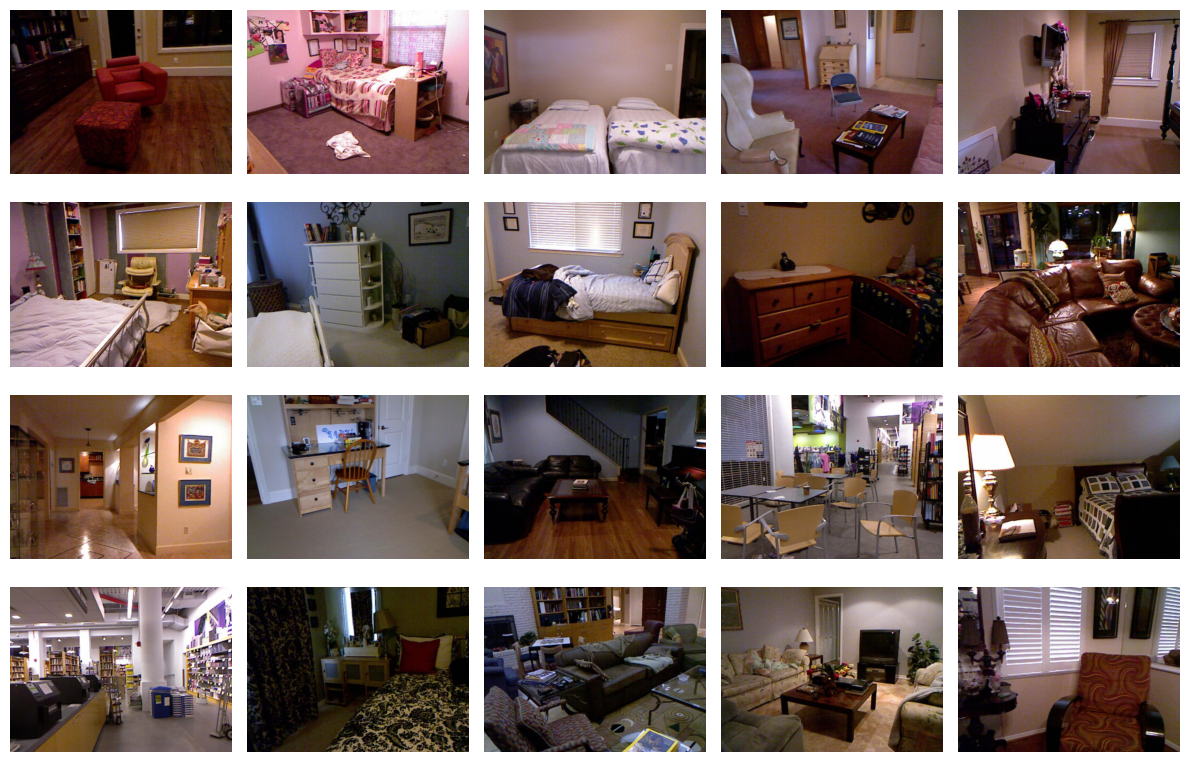

In [42]:
def plot_random_images_from_folder(folder_path, num_images=20,  seed=42):
    random.seed(seed)

    # Get a list of image files in the folder
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg', '.gif'))]

    # Ensure that we have at least num_images files to choose from
    if len(image_files) < num_images:
        raise ValueError("Not enough images in the folder")

    # Randomly select num_images image files
    selected_files = random.sample(image_files, num_images)

    # Create a subplot grid
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

    for i, file_name in enumerate(selected_files):
        # Open and display the image using PIL
        img = Image.open(os.path.join(folder_path, file_name))

        if num_rows == 1:
            ax = axes[i % num_cols]
        else:
            ax = axes[i // num_cols, i % num_cols]
  
        ax.imshow(img)
        ax.axis('off')
        # ax.set_title(file_name)

    # Remove empty subplots
    for i in range(num_images, num_rows * num_cols):
        if num_rows == 1:
            fig.delaxes(axes[i % num_cols])
        else:
            fig.delaxes(axes[i // num_cols, i % num_cols])

    plt.tight_layout()
    plt.show()

plot_random_images_from_folder(r"C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\test\images", num_images=20, seed=42)


In [43]:
def get_image_properties(image_path):
    # Read the image file
    img = cv2.imread(image_path)

    # Check if the image file is read successfully
    if img is None:
        raise ValueError("Could not read image file")

    # Get image properties
    properties = {
        "width": img.shape[1],
        "height": img.shape[0],
        "channels": img.shape[2] if len(img.shape) == 3 else 1,
        "dtype": img.dtype,
    }

    return properties
    
img_properties = get_image_properties(example_image_path)
img_properties


{'width': 620, 'height': 460, 'channels': 3, 'dtype': dtype('uint8')}

In [ ]:
def get_class_statistics(label_folders, class_names):
    stats = {mode: {name: 0 for name in class_names} for mode in label_folders.keys()}

    for mode, folder_path in label_folders.items():
        label_files = glob.glob(os.path.join(folder_path, '*.txt'))
        
        for file_path in label_files:
            with open(file_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    class_id = int(line.strip().split()[0])
                    if class_id < len(class_names):
                        stats[mode][class_names[class_id]] += 1
    
    return stats

label_folders = {
    'train': r'C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\train\labels',
    'valid': r'C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\valid\labels',
    'test': r'C:\Users\Admin\Desktop\GoIT\DLMVNLP\HW8\test\labels'
}

class_names = yaml_data['names']
dataset_stats = get_class_statistics(label_folders, class_names)

# Convert the statistics to a pandas DataFrame for easier plotting
dataset_stats_df = pd.DataFrame(dataset_stats).reset_index().rename(columns={'index': 'Class'})
dataset_stats_df = dataset_stats_df.melt(id_vars='Class', var_name='Mode', value_name='Count')

print("Class Distribution:")
print(pd.DataFrame(dataset_stats))

Class Distribution:
                  train  valid  test
door                479     97    34
cabinetDoor        3178    765   179
refrigeratorDoor    689    192     2
window              403     91    63
chair               204     49    87
table               228     40    47
cabinet             179     32    52
couch                27      1    58
openedDoor           78     13    20
pole                 27      9     8


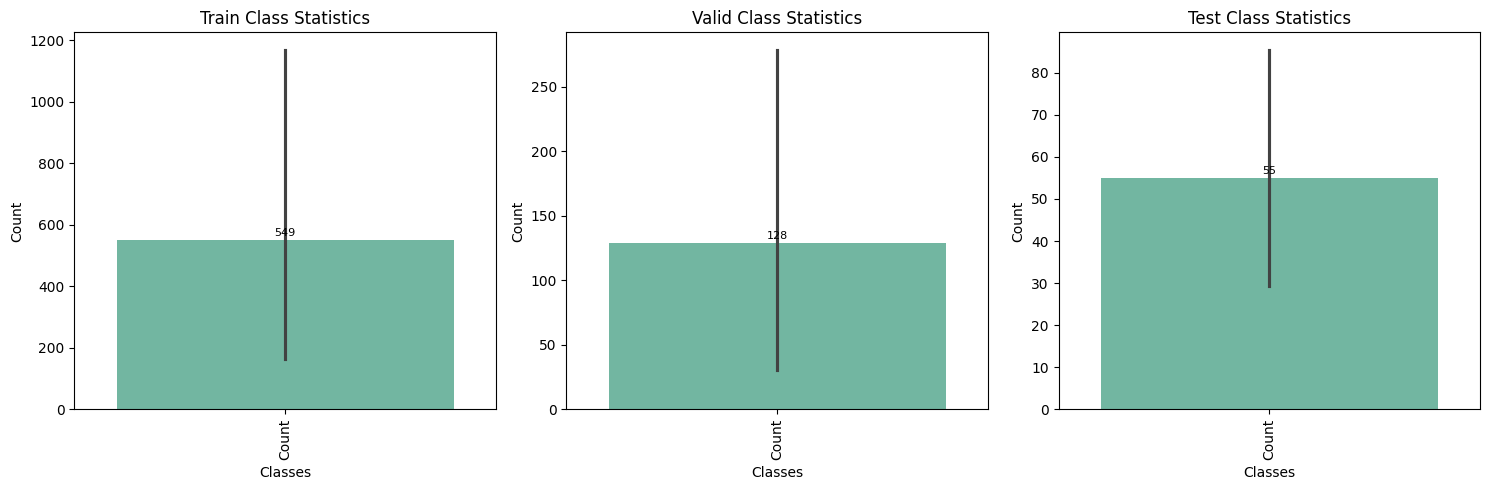

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot vertical bar plots for each mode in subplots
for i, mode in enumerate(['train', 'valid', 'test']):
    sns.barplot(
        data=dataset_stats_df[dataset_stats_df['Mode'] == mode].drop(columns='Mode'),
        orient='v',
        ax=axes[i],
        palette='Set2'
    )
    
    axes[i].set_title(f'{mode.capitalize()} Class Statistics')
    axes[i].set_xlabel('Classes')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=90) 

    # Add annotations on top of each bar
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.show()


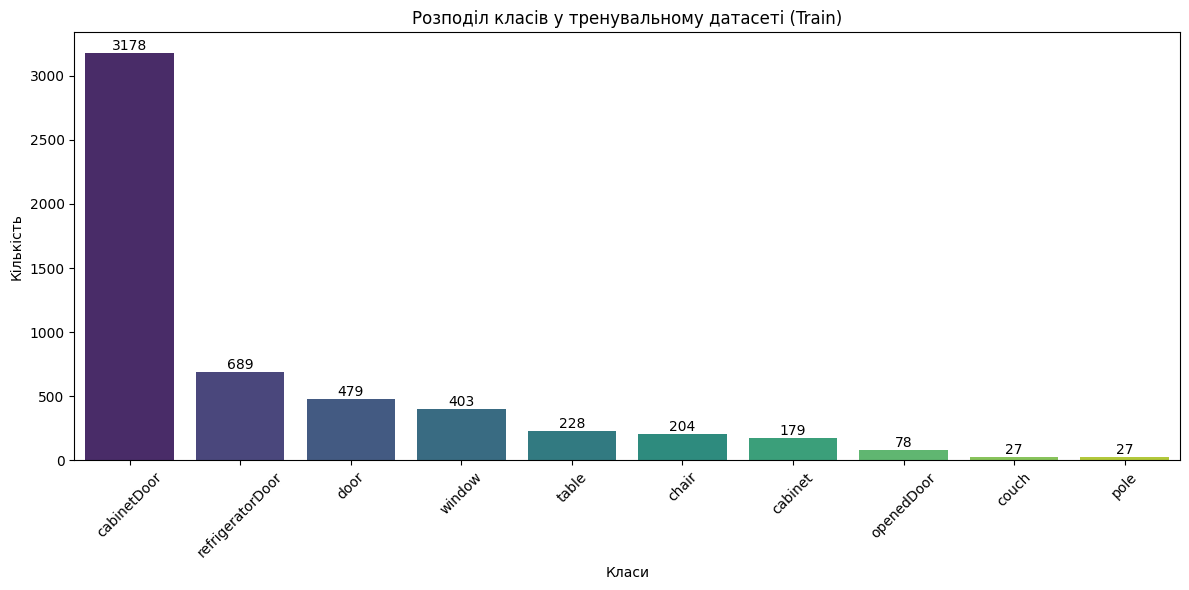

In [ ]:
train_stats_df = dataset_stats_df[dataset_stats_df['Mode'] == 'train'].copy()
train_stats_df = train_stats_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=train_stats_df, x='Class', y='Count', palette='viridis')

plt.title('Розподіл класів у тренувальному датасеті (Train)')
plt.xlabel('Класи')
plt.ylabel('Кількість')
plt.xticks(rotation=45)

for index, value in enumerate(train_stats_df['Count']):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [46]:
def main():
    model = YOLO('yolov10m.pt') 

    results = model.train(
        data='data.yaml',
        epochs=100,              
        imgsz=640,               
        batch=16,                
        device=0,                
        workers=12,              
        optimizer='AdamW',       
        patience=10,             
        save=True,
        project='indoor_projects',
        name='yolov10m_optimized',
        cos_lr=True,             
        augment=True             
    )

main()

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.12.10 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10m_op